In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as spy
from sklearn.neighbors import KernelDensity
from statsmodels.nonparametric.smoothers_lowess import lowess
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from tqdm.auto import tqdm

/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#import local packages
from DPosIT import DPosIT
from em_nuc_model import EMNucModel
from exo_model import ExoModel
from nucleosomes import Nucleosome

In [1196]:
def make_position_matrix(batch, grouped_var=None, start=None, stop=None):
    starts, stops = batch[:, 0], batch[:, 1]
    return _make_position_matrix(starts, stops, grouped_var, start, stop)

def _make_position_matrix(starts, stops, grouped_var=None, start=None, stop=None):
    grouped_var = np.ones_like(starts) if grouped_var is None else grouped_var
    min_start = start if start else starts.min()
    stop = stop if stop else stops.max()
    imshow = np.zeros((starts.size, stop - min_start))
    for i, (cur_start, cur_stop) in enumerate(zip(starts, stops)):
        imshow[i, cur_start - min_start : cur_stop - min_start] = grouped_var[i]
    return imshow


def count_statistics(batch, model):
    prob_matrix = model.model.gij
    window_data = pd.DataFrame(batch, columns=['start', 'stop'])
    window_data['mid'] = (window_data.start + window_data.stop) / 2
    nuc_indxex = np.argmax(prob_matrix, axis=1)
    window_data["dyad"] = model.positions_[nuc_indxex]
    window_data["dyadLH"] = np.max(prob_matrix, axis=1)
    window_data["tempLH"] = model.model.X.sum(axis=1)
    window_data['dyad_prob'] = model.weights_[nuc_indxex]
    statistics = make_stat_df(window_data)
    return window_data, statistics


def make_stat_df(window_data):
    group_size = window_data.groupby("dyad").size().reset_index()
    group_size.name = 'size'
    group_size.rename(columns={0: 'size'}, inplace=True)
    window_data['stat'] = window_data.dyad - window_data.mid
    window_data['stat'] = window_data.groupby('dyad', group_keys=False).stat.apply(lambda x: x  / x.std() )
    window_data['stat'] = window_data['stat'] ** 2
    norm1 = window_data.groupby('dyad').stat.agg(sum)
    norm1.name = 'stat'
    statistics = pd.merge(norm1, group_size, on='dyad').reset_index(drop=True)
    p_values = [1 - spy.stats.chi2.cdf(row.stat, row['size']) for i, row in statistics.iterrows()]
    statistics['p_vals'] = p_values
    return statistics


def make_coverage(batch, start, stop):
    x = np.zeros(stop - start + 400)
    broad_start = start - 200
    lefts, rights = batch[:, 0], batch[:, 1]
    for left, right in zip(lefts, rights):
        x[left - broad_start : right - broad_start] += 1
    return x[200 : -200]


def plot_model_occ(dyads, nuc_template, start, end, dyad_weights=None):
    dyad_weights = np.ones_like(dyads) if dyad_weights is None else dyad_weights
    broad_start, broad_end = start - nuc_template.size, end + nuc_template.size
    # print(broad_start, broad_end)
    x = np.arange(broad_start, broad_end)
    y = np.zeros_like(x, dtype=float)
    for i, dyad in enumerate(dyads):
        start_pos = dyad - nuc_template.size // 2 - broad_start
        end_pos = dyad - broad_start + nuc_template.size // 2
        y[start_pos : end_pos] += nuc_template * dyad_weights[i]
    return x[nuc_template.size : -nuc_template.size], y[nuc_template.size : -nuc_template.size]

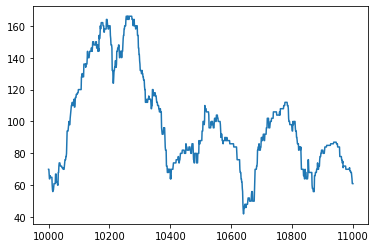

In [1197]:
plt.plot(np.arange(10000, 11000), make_coverage(batch, 10000, 11000))

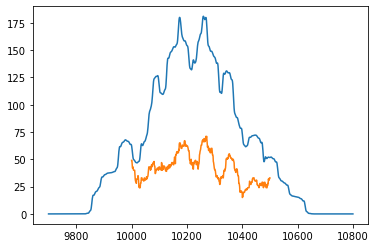

In [676]:
nx, ny = plot_model_occ(stat_df, nuc_template, start-300, stop+300)
plt.plot(nx, ny)
plt.plot(np.arange(start, stop), coverage)

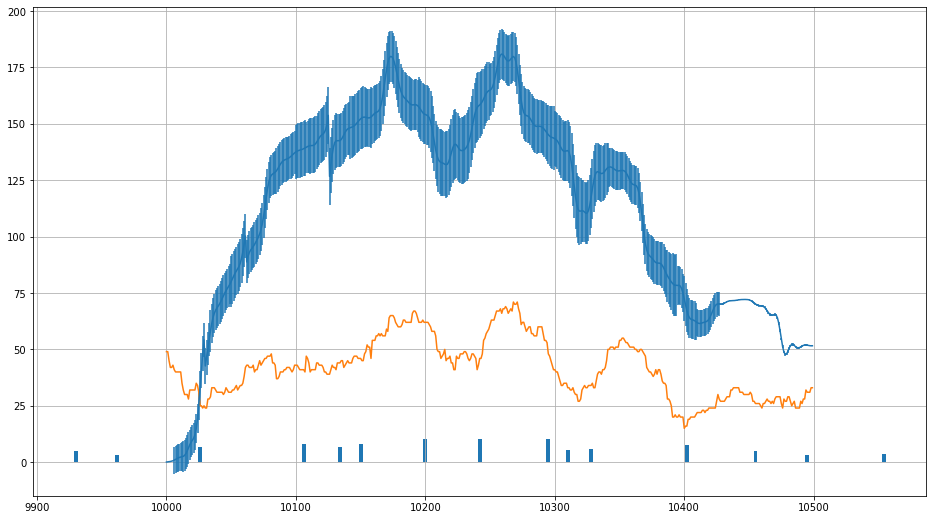

In [677]:
nx, ny = plot_model_occ(stat_df, nuc_template, start, stop)
sx, sy = plot_model_std(stat_df, std_template, start, stop)

plt.figure(figsize=(16, 9))
plt.errorbar(nx, ny, sy / np.sqrt(coverage))
plt.plot(np.arange(start, stop), coverage)
plt.bar(theta_opt, 100 * w_opt, 3)
plt.grid()

In [679]:
stop

10500

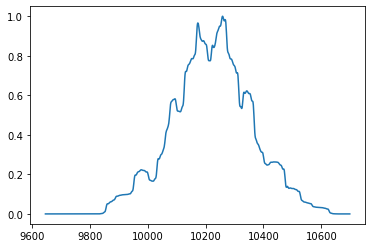

In [512]:
plt.plot(x, scaler.fit_transform(y.reshape(-1, 1)).flatten(), label='model')

In [609]:


# plt.plot(nx, ny, label='model')
# sns.lineplot(x=np.arange(start, stop), y=coverage, label='exp', errorbar=sy / np.sqrt(coverage))
# plt.plot(sx, sy / np.sqrt(coverage), label='std')
# plt.grid()
# plt.legend()

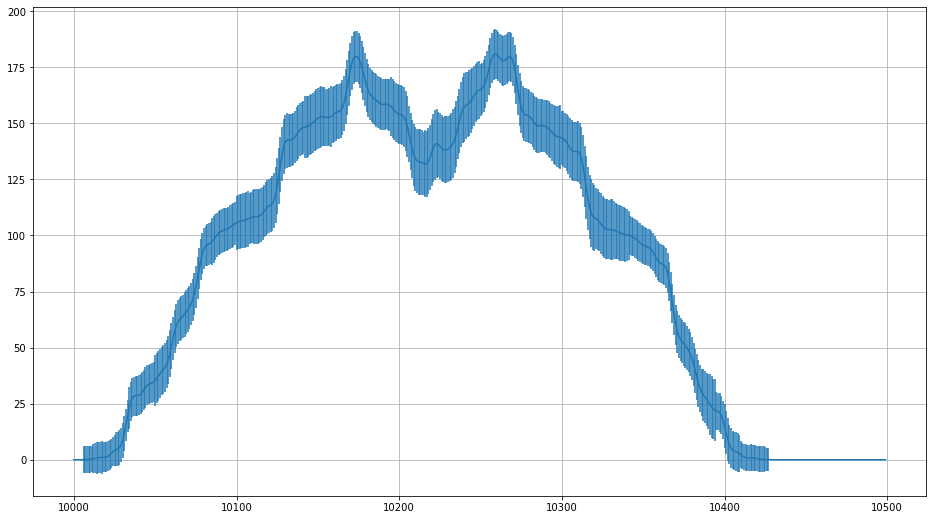

In [628]:
plt.figure(figsize=(16, 9))
plt.errorbar(nx, ny, yerr=sy / np.sqrt(coverage))

plt.grid()

array([0.03870968, 0.07096774, 0.04516129, 0.03225806, 0.0688172 ,
       0.03225806, 0.03225806, 0.09032258, 0.03870968, 0.05376344,
       0.04731183, 0.07741935, 0.04086022, 0.08172043, 0.06236559,
       0.04086022, 0.0344086 , 0.04516129, 0.06666667])

In [5]:
# MNASE1 = "data/reads/MNase_1/mapping/mnase_99_147_nodup.sam"
exo_sam = "/home/d_ryabov/MiSeq/scripts/data/reads/MNase-Exo_less2/SRR1802184_99_147_nodup.sam"

In [6]:
dpst = DPosIT(exo_sam, 'sam', 'tmp', reg_koef=0.18, max_iter=1000)
dpst.fit_exo('model_data/exo_probs.csv')
# plt.plot(dpst.fit_res)

/home/d_ryabov/MiSeq/NucDPosIT/src/NucDPosIT/Alignment_file_manager.py:71: UserWarning: found BAM file
  warnings.warn("found BAM file")
/home/d_ryabov/MiSeq/NucDPosIT/src/NucDPosIT/Alignment_file_manager.py:80: UserWarning: index found
  warnings.warn("index found")


ExoModel(max_iter=1000)

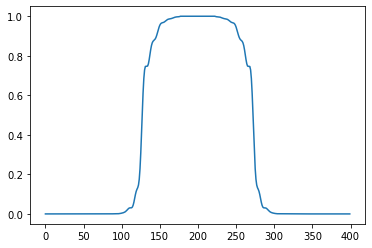

In [926]:
N = 10000000
kde = KernelDensity()

digested_nucs = dpst.digest_nucs(N)
pos = np.array(list(map(lambda x: [x.start, x.end], digested_nucs)))
nuc_template = make_position_matrix(pos, start=-200, stop=200).sum(axis=0) / N
plt.plot(nuc_template)

In [927]:
# class OccupancyNucsMixin:
#     def __init__(self, nuc_template):
#         self.__nuc_template = nuc_template
        
#     @property
#     def nuc_template(self):
#         return self.__nuc_template
    
#     def 

In [930]:
def nuc_occupancy_prob(nuc_pos, dyad, template):
    rel_nucpos = nuc_pos - dyad + template.size // 2
    if rel_nucpos >= 0 and rel_nucpos < len(template):
        return template[rel_nucpos]
    else:
        return 0

In [ ]:
def plot_model_occ(dyads, nuc_template, start, end, dyad_weights=None):
    dyad_weights = np.ones_like(dyads) if dyad_weights is None else dyad_weights
    broad_start, broad_end = start - nuc_template.size, end + nuc_template.size
    # print(broad_start, broad_end)
    x = np.arange(broad_start, broad_end)
    y = np.zeros_like(x, dtype=float)
    for i, dyad in enumerate(dyads):
        start_pos = dyad - nuc_template.size // 2 - broad_start
        end_pos = dyad - broad_start + nuc_template.size // 2
        y[start_pos : end_pos] += nuc_template * dyad_weights[i]
    return x[nuc_template.size : -nuc_template.size], y[nuc_template.size : -nuc_template.size]

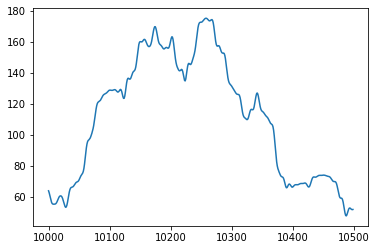

In [1104]:
x, y = plot_model_occ(window_df.dyad.to_numpy(), nuc_template, 10000, 10500)
plt.plot(x, y)

array([ 9930,  9930,  9930,  9930,  9930,  9930,  9930,  9930,  9952,
        9930,  9930, 10049,  9952,  9930,  9952,  9952,  9952,  9930,
        9930,  9952,  9930,  9952,  9930,  9930, 10049, 10049, 10049,
       10049, 10049, 10004, 10049, 10049,  9952,  9952,  9952,  9952,
        9952, 10049,  9952,  9952, 10049,  9952,  9952,  9952,  9952,
       10004,  9952,  9952, 10004, 10088, 10088, 10088, 10088, 10088,
       10088, 10088, 10004, 10004, 10004, 10106, 10106, 10106, 10004,
       10004, 10106, 10106, 10106, 10106, 10106, 10106, 10106, 10106,
       10004, 10004, 10049, 10004, 10004, 10004, 10004, 10134, 10049,
       10134, 10134, 10134, 10049, 10106, 10134, 10134, 10134, 10134,
       10134, 10134, 10134, 10134, 10049, 10134, 10150, 10150, 10150,
       10049, 10134, 10150, 10134, 10049, 10134, 10150, 10150, 10049,
       10150, 10049, 10049, 10150, 10134, 10150, 10150, 10150, 10150,
       10088, 10150, 10150, 10150, 10049, 10088, 10150, 10088, 10150,
       10200, 10200,

In [1005]:
def plot_occupancy(dyad_positions, weights, start, end, template):
    x = np.arange(start, end)
    y = np.zeros_like(x, dtype=float)
    for nuc_pos in range(start, end):
        for dyad_pos, dyad_weight in zip(dyad_positions, weights):
            y[nuc_pos - start] += nuc_occupancy_prob(nuc_pos, dyad_pos, template) * dyad_weight
    return x, y
        

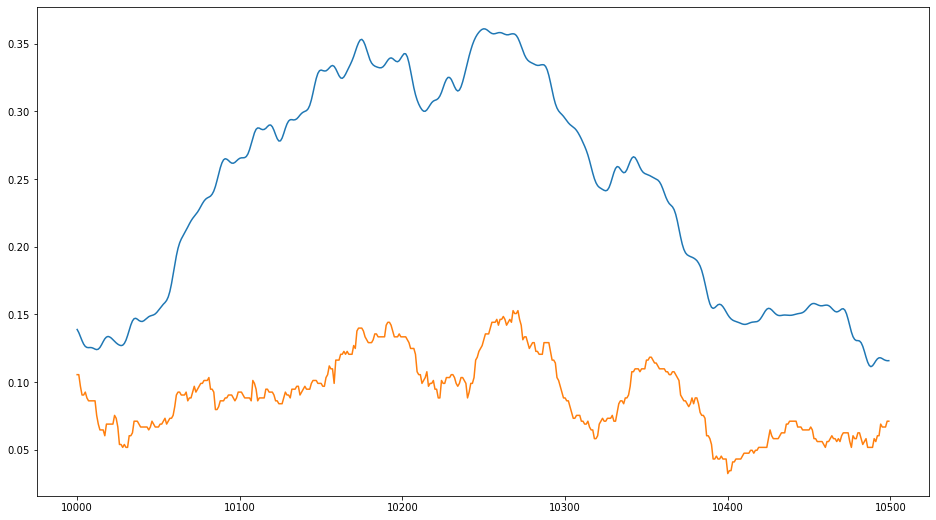

In [1006]:
x, y = plot_occupancy(model.positions_, model.weights_, start, stop, nuc_template)


plt.figure(figsize=(16, 9))
plt.plot(x, y)
plt.plot(np.arange(start, stop), coverage / len(batch))

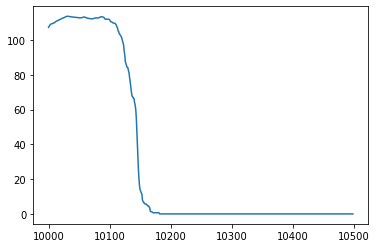

In [1003]:
plt.plot(x, y)

In [1107]:
batch.shape

(465, 2)

In [1108]:
window_df

,start,stop,mid,dyad,dyadLH,tempLH,dyad_prob,stat,fold
0,9858,10002,9930.0,9930,0.996815,0.000382,0.040860,0.000000,0
1,9878,10002,9940.0,9930,0.603922,0.000092,0.040860,3.271538,0
2,9876,10002,9939.0,9930,0.697709,0.000064,0.040860,2.649945,0
3,9854,10002,9928.0,9930,0.998019,0.000210,0.040860,0.130862,0
4,9855,10002,9928.5,9930,0.998326,0.000315,0.040860,0.073610,0
...,...,...,...,...,...,...,...,...,...
460,10494,10645,10569.5,10564,1.000000,0.000022,0.032258,0.297457,0
461,10494,10639,10566.5,10564,1.000000,0.000113,0.032258,0.061458,0
462,10494,10629,10561.5,10564,1.000000,0.000016,0.032258,0.061458,0
463,10498,10565,10531.5,10464,0.000000,0.000000,0.055914,13.255095,0


0.0038059

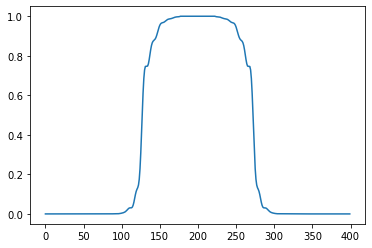

In [952]:
plt.plot(nuc_template)
nuc_occupancy_prob(100, 200, nuc_template)

In [942]:
window_df.

,start,stop,mid,dyad,dyadLH,tempLH,dyad_prob,stat,fold,id_
0,9858,10002,9930.0,9930,0.992616,0.000242,0.025806,0.000000,0,985810002
1,9878,10002,9940.0,9952,0.604287,0.000088,0.053763,1.132951,0,987810002
2,9876,10002,9939.0,9952,0.502196,0.000057,0.053763,1.329644,0,987610002
3,9854,10002,9928.0,9930,0.995399,0.000133,0.025806,0.201281,0,985410002
4,9855,10002,9928.5,9930,0.996111,0.000199,0.025806,0.113220,0,985510002
...,...,...,...,...,...,...,...,...,...,...
460,10494,10645,10569.5,10564,1.000000,0.000022,0.032258,0.297457,0,1049410645
461,10494,10639,10566.5,10564,1.000000,0.000113,0.032258,0.061458,0,1049410639
462,10494,10629,10561.5,10564,1.000000,0.000016,0.032258,0.061458,0,1049410629
463,10498,10565,10531.5,10220,0.000000,0.000000,0.086022,41.239985,0,1049810565


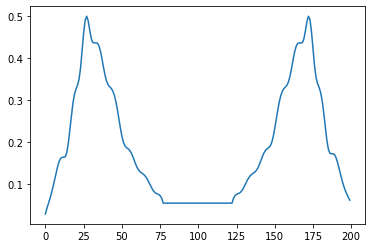

In [578]:
std_template = make_position_matrix(pos, start=-100, stop=100).std(0)
plt.plot(std_template)

In [486]:
ntrials = 100000
nofreads = 20
mean_df = []
std_df = []

for nreads in tqdm(range(1, nofreads + 1), total=nofreads):
    mksym = []
    for i in range(ntrials):
        samples = dpst.digest_nucs(nreads)
        pos = np.array(list(map(lambda x: [x.start, x.end], samples)))
        pos_matrix = make_position_matrix(pos, start=-200, stop=200).sum(axis=0)
        mksym.append(pos_matrix)
    mksym = np.array(mksym)
    mean_df.append(mksym.mean(0))
    std_df.append(mksym.std(0))
    
mean_df = pd.DataFrame(mean_df, index=np.arange(1, nofreads + 1))
std_df = pd.DataFrame(std_df, index=np.arange(1, nofreads + 1))

100%|██████████| 20/20 [04:23<00:00, 13.18s/it]


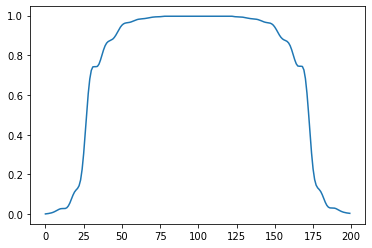

In [490]:
# mean_df.iloc[9].T.plot()
plt.plot(nuc_template)

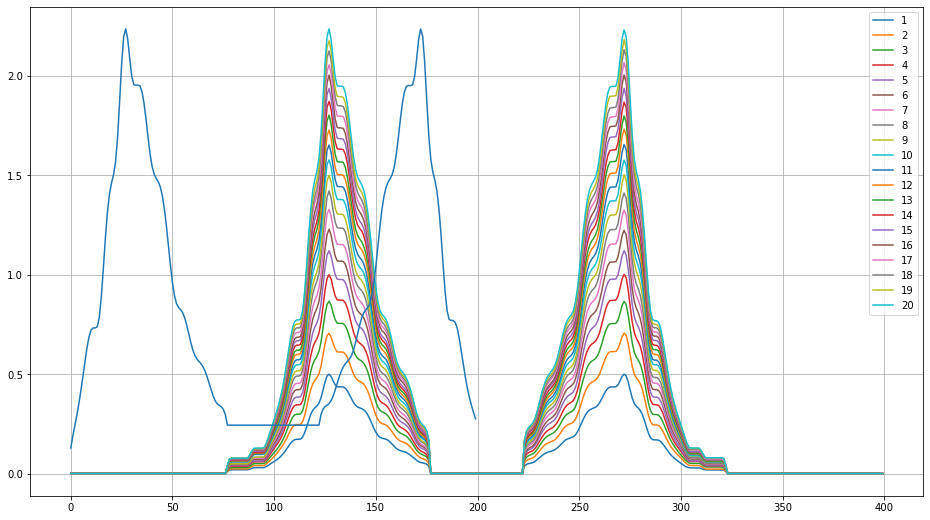

In [1232]:
# plt.figure()
std_df.T.plot(figsize=(16, 9))
plt.plot(std_template * np.sqrt(20))
plt.grid()

<ErrorbarContainer object of 3 artists>

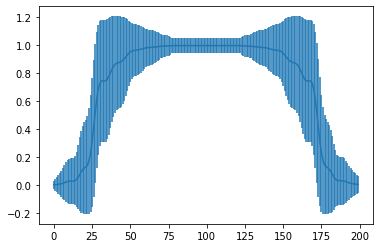

In [853]:
nreads = 1
plt.errorbar(x = np.arange(nuc_template.size), y=nuc_template, yerr=std_template / np.sqrt(nreads))

In [572]:
std_df

,0,1,2,3,4,5,6,7,8,9,...,390,391,392,393,394,395,396,397,398,399
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
mkdf = pd.DataFrame(mksym)

<AxesSubplot:>

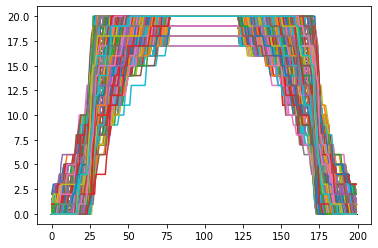

In [12]:
mkdf.T.plot(legend=False)

<AxesSubplot:>

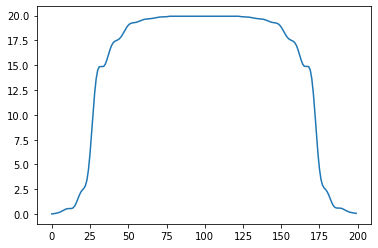

In [13]:
mkdf.mean().plot()

<AxesSubplot:>

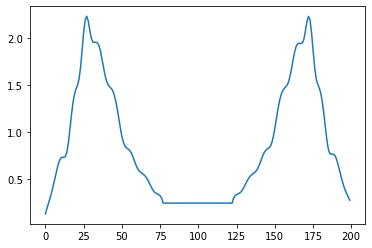

In [14]:
mkdf.std().plot()

In [15]:
chromosomes = dpst.file_manager.chromosomes
chromosomes

('NC_001133.9',
 'NC_001134.8',
 'NC_001135.5',
 'NC_001136.10',
 'NC_001137.3',
 'NC_001138.5',
 'NC_001139.9',
 'NC_001140.6',
 'NC_001141.2',
 'NC_001142.9',
 'NC_001143.9',
 'NC_001144.5',
 'NC_001145.3',
 'NC_001146.8',
 'NC_001147.6',
 'NC_001148.4',
 'NC_001224.1')

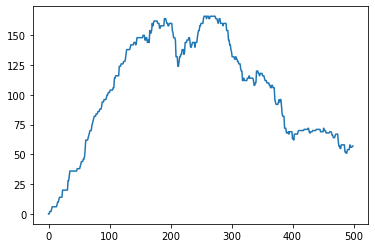

In [1124]:
c = coverage(batch, 10000, 10500)
plt.plot(c)

In [1125]:
c.shape

(500,)

100%|██████████| 5000/5000 [06:03<00:00, 13.76it/s]


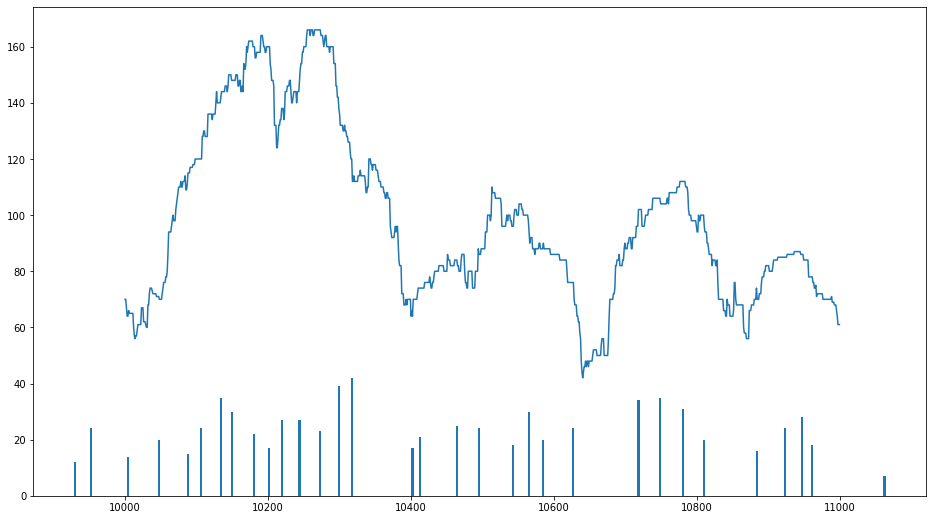

In [1319]:
n_nucs = 40
winlen = 1000
start = 10000
stop = 11000
chromosome = 'NC_001133.9'

model = EMNucModel(n_nucs, 'DROPSEM', dpst.fit_res, max_iter=5000, alpha=0.01)

plt.figure(figsize=(16, 9))
stat_df = pd.DataFrame()
window_df = pd.DataFrame()

for i, batch in enumerate(dpst.iterover(chromosome, win_len=winlen, start=start, stop=stop, step=100)):
    model.fit(batch)
    w_opt, theta_opt = model.weights_, model.positions_
    cluster_occ = model.cluster_occupancy()
    plt.bar(theta_opt, cluster_occ, 3)
    
    window_data, cur_stat = count_statistics(batch, model)
    window_data['fold'] = i

    # plt.figure(figsize=(16, 9))
    # sns.histplot(model.model.X.sum(axis=1), kde=True, bins=50)
    # plt.show()
    
    
    stat_df = pd.concat([stat_df, cur_stat])
    window_df = pd.concat([window_df, window_data])
    
    # _ = plt.hist(model.model.X.sum(axis=1), bins=100)
    # plt.show()
    
stat_df.reset_index(drop=True, inplace=True)
window_df.reset_index(drop=True, inplace=True)
coverage = make_coverage(window_df[['start', 'stop']].to_numpy(), start, stop)
plt.plot(np.arange(start, stop), coverage)

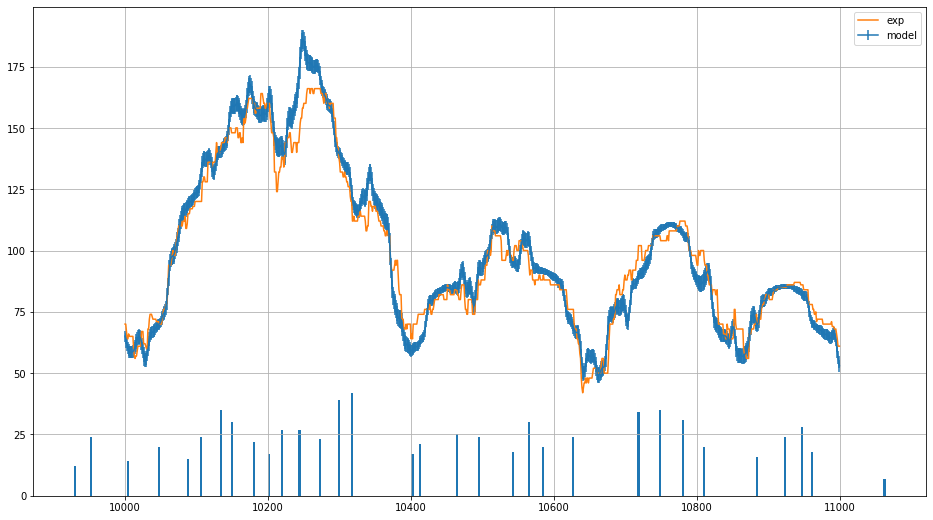

In [1322]:
dyad_x, dyad_y = plot_model_occ(window_df.dyad.to_numpy(), nuc_template, start, stop)

weights = window_df.dyad.apply(lambda x: stat_df.loc[stat_df.dyad == x, 'size'].values[0]).to_numpy()
sem_x, sem_y = plot_model_occ(window_df.dyad.to_numpy(), std_template ** 2, start, stop, weights)

plt.figure(figsize=(16, 9))
plt.errorbar(dyad_x, dyad_y, np.sqrt(var_y), label='model')
plt.plot(np.arange(start, stop), coverage, label='exp')
plt.bar(theta_opt, cluster_occ, 3)
plt.legend()
plt.grid()

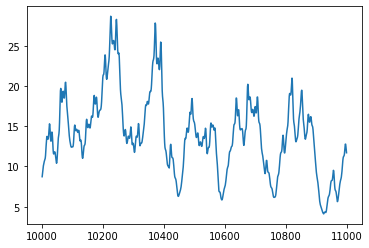

In [1321]:
plt.plot(sem_x, np.sqrt(sem_y))

<AxesSubplot:ylabel='Density'>

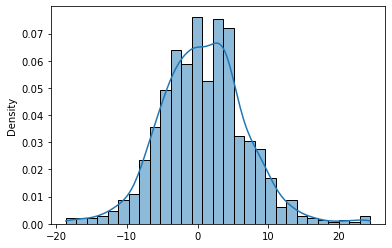

In [1220]:
v = dyad_y - coverage
# v = (v - v.mean()) / v.std()

sns.histplot(v, kde=True, stat='density')

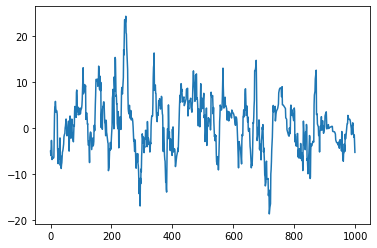

In [1221]:
plt.plot(v)

<AxesSubplot:ylabel='Count'>

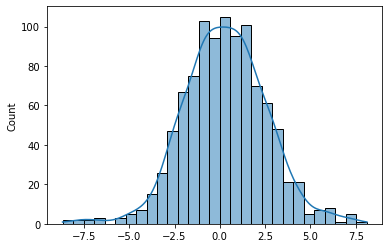

In [1224]:
sns.histplot(v / np.sqrt(var_y), kde=True)

In [1069]:
window_df.groupby(['stat', 'fold']).tempLH.max()

stat       fold
0.000000   0       1.301349e-03
0.000032   0       7.070650e-04
0.000542   0       1.648882e-03
0.000593   0       1.368699e-04
0.000880   0       1.259562e-03
                       ...     
5.423217   0       2.146600e-08
5.467782   0       4.147303e-09
5.697979   0       3.775179e-09
6.599552   0       5.414965e-09
30.092561  0       0.000000e+00
Name: tempLH, Length: 215, dtype: float64

In [1070]:
t = window_df[['start', 'stop']].astype(str)
window_df.loc[:, 'id_'] = (t.start + t.stop)

In [1071]:
filtered_df = window_df.groupby('id_', group_keys=False).apply(lambda x: x.nlargest(1, 'tempLH')).drop(columns="id_")
filtered_stat = make_stat_df(filtered_df)

array([[<AxesSubplot:title={'center':'dyadLH'}>,
        <AxesSubplot:title={'center':'tempLH'}>]], dtype=object)

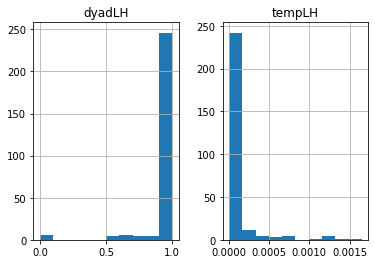

In [1072]:
filtered_df[['dyadLH', 'tempLH']].hist()

<AxesSubplot:ylabel='Density'>

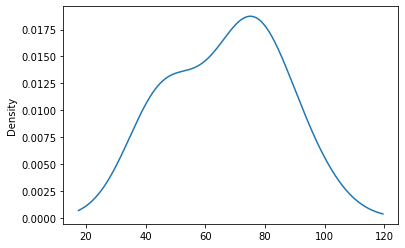

In [1073]:
stat_df.sort_values('dyad').dyad.diff().plot.kde()

In [1053]:
window_df.id_.unique().shape

(272,)

In [1167]:
x, y = plot_model_occ(stat_df, nuc_template, start, stop)
stdx, stdy = plot_model_std(stat_df, std_template, start, stop)


plt.figure(figsize=(16, 9))
plt.plot(np.arange(start, stop), coverage / batch.size, label='exp')
# plt.plot(x, y)
# plt.errorbar(x, y, stdy / np.sqrt(coverage))

TypeError: unsupported operand type(s) for -: 'str' and 'int'

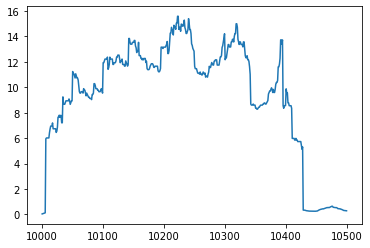

In [704]:
stdx, stdy = plot_model_std(stat_df, std_template, start, stop)
plt.plot(stdx, stdy / np.sqrt(coverage))

In [711]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


# plt.plot(scaler.fit_transform(x.reshape(-1, 1)))
# plt.bar(theta_opt, w_opt, 5)

w_opt = (stat_df['size'] / stat_df['size'].sum()).to_numpy()
theta_opt = stat_df.dyad.to_numpy()
x, y = plot_model_occ(window_df, nuc_template)


    
plt.figure(figsize=(16, 9))
plt.plot(x, scaler.fit_transform(y.reshape(-1, 1)).flatten(), label='model')
plt.plot(np.arange(start, stop), scaler.fit_transform(coverage.reshape(-1, 1)), label='exp')
plt.bar(stat_df.dyad, scaler.fit_transform(stat_df['size'].to_numpy().reshape(-1, 1)).flatten(), 3, color='green')
plt.legend()

TypeError: plot_model_occ() missing 2 required positional arguments: 'start' and 'stop'

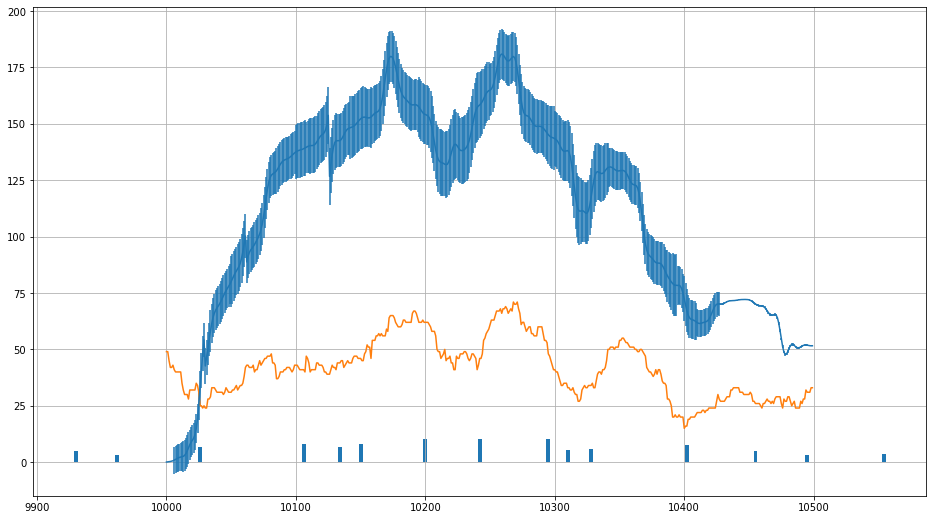

In [710]:
nx, ny = plot_model_occ(stat_df, nuc_template, start, stop)
sx, sy = plot_model_std(stat_df, std_template, start, stop)

plt.figure(figsize=(16, 9))
plt.errorbar(nx, ny, sy / np.sqrt(coverage))
plt.plot(np.arange(start, stop), coverage)
plt.bar(theta_opt, 100 * w_opt, 3)
plt.grid()

In [ ]:
plt.plot(np.arange(start, stop), coverage)to_numpy

In [ ]:
np.arange(x_start, x_stop).shape

In [ ]:
# stat_df

In [ ]:
sort_df = window_df.sort_values('mid')

In [ ]:
plt.figure(figsize=(16, 9))
(sort_df.mid - sort_df.dyad).hist(bins=np.arange(-100, 100, 1), density=True)

In [ ]:
stat_df.sort_values('dyad').dyad.diff().hist(bins=np.arange(0, 120, 1))

In [ ]:
# final_model = EMNucModel(stat_df.shape[0], 'DROPSEM', dpst.fit_res, max_iter=300)
# final_model.fit(window_df[['start', 'stop']].to_numpy(), (stat_df['size'] / stat_df['size'].sum()).to_numpy(), stat_df.dyad.to_numpy())

In [ ]:
# final_df, final_stat = count_statistics(window_df[['start', 'stop']].to_numpy(), final_model)

In [ ]:
# fig, ax = plt.subplots(1, 1, figsize=(16, 9), sharex=True, sharey=True)

# ax.plot(np.arange(start, stop), coverage)
# ax.bar(final_stat.dyad, final_stat['size'], 3, color='orange')
# # sns.barplot(data=stat_df, x='dyad', y=stat_df['size'], ax=ax)
# ax.set_xlabel('координата, п.н.')
# ax.set_ylabel("заселенность, прочтения")

In [ ]:
argsort = np.argsort(model.positions_)

In [ ]:
plt.figure(figsize=(16, 9))
plt.imshow(model.model.gij.T[argsort, :])

In [ ]:
plt.figure(figsize=(16, 9))
plt.imshow(model.model.X.T[argsort, :])

In [ ]:
# window_df.to_csv('tmp/window_df/window_df.csv')

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9), sharex=True, sharey=True)

ax.plot(np.arange(start, stop), coverage)
ax.bar(filtered_stat.dyad, filtered_stat['size'], 3, color='orange')
# sns.barplot(data=stat_df, x='dyad', y=stat_df['size'], ax=ax)
ax.set_xlabel('координата, п.н.')
ax.set_ylabel("заселенность, прочтения")

In [ ]:
# fig, ax = plt.subplots(1, 1, figsize=(16, 9), sharex=False, sharey=False)
# sns.barplot(data=window_df.groupby(['fold', 'dyad']).size().reset_index(), x='dyad', y=0, hue='fold')
# sns.lineplot(x=np.arange(start, stop), y=coverage)

In [ ]:
gij = model.model.gij
plt.figure(figsize=(16, 9))
plt.imshow(gij)

In [ ]:
window_df.drop_duplicates(inplace=True)

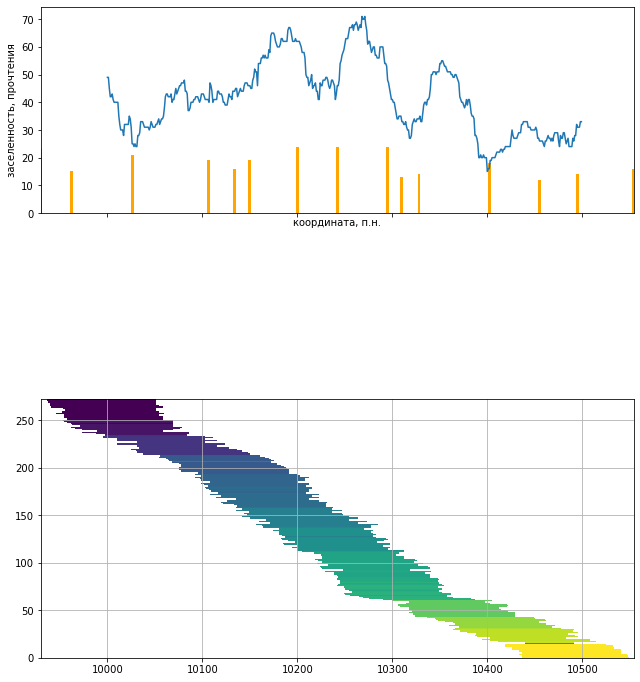

In [684]:
fig,ax = plt.subplots(2,1,figsize=( 9,14),
                      gridspec_kw=dict(height_ratios=[2, 9]),
                     sharex=True
                     )

ax[0].plot(np.arange(start, stop), coverage)
ax[0].bar(filtered_stat.dyad, filtered_stat['size'], 3, color='orange')
ax[0].set_xlabel('координата, п.н.')
ax[0].set_ylabel("заселенность, прочтения")
# ax[0].grid()

grouped_var = filtered_df.sort_values("mid").dyad.to_numpy()
data = make_position_matrix(filtered_df.sort_values("mid")[['start', 'stop']].to_numpy(), grouped_var)
data[data==0] =  np.nan
# data -= data[0,0]
ax[1].imshow(data, extent=(np.nanmin(stat_df.dyad), np.nanmax(stat_df.dyad), 0, data.shape[0]))
# ax[1].bar(stat_df.dyad, np.ones_like(stat_df.dyad) * data.shape[0], 3, color='orange')
plt.tight_layout()
ax[1].grid()
fig.savefig('tmp/pictures/double_imshow.pdf')

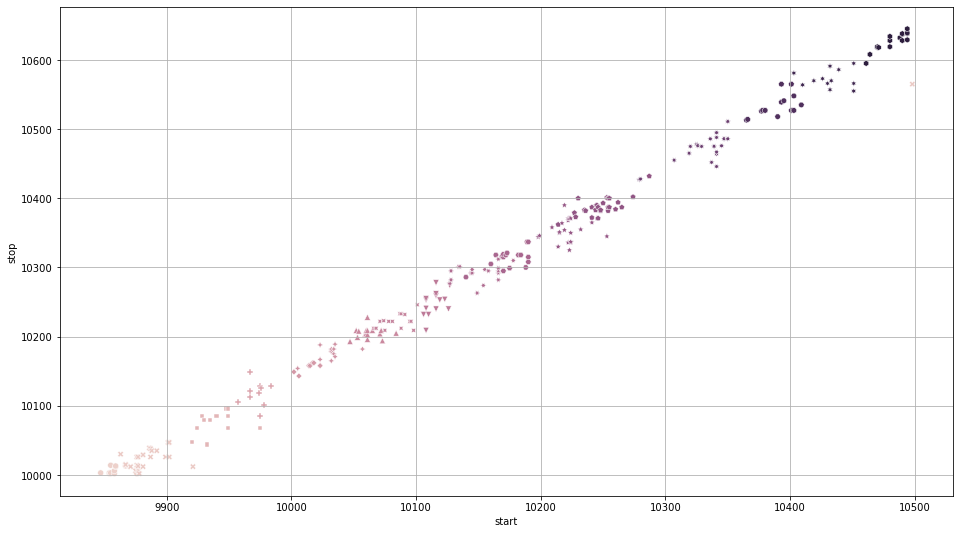

In [49]:
# sns.kdeplot(data=df, x='start', y='stop')
plt.figure(figsize=(16, 9))
sns.scatterplot(data=filtered_df, x='start', y='stop', style='dyad', hue='dyad', legend=False)
plt.grid()

In [50]:
test_grid = {'n_nucs': np.arange(2, 20),
            'cluster_strategy': ['SEM', 'DROPSEM'],
            'alpha': np.arange(1, 11) / 100,
            'max_iter': [1000, 2000]}
gs = GridSearchCV(EMNucModel(1, 'SEM', dpst.fit_res, 1000), test_grid, n_jobs=32, verbose=True)

In [51]:
gs_res = gs.fit(batch)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


100%|██████████| 2000/2000 [00:59<00:00, 33.81it/s]


In [55]:
resdf = pd.DataFrame(gs_res.cv_results_)

In [57]:
resdf.sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_cluster_strategy,param_max_iter,param_n_nucs,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
35,120.638700,12.159107,0.013335,0.009450,0.01,SEM,2000,19,"{'alpha': 0.01, 'cluster_strategy': 'SEM', 'ma...",-10725.933394,-1015.955872,-1005.146442,-1019.924364,-12715.532785,-5296.498571,5282.966345,1
592,63.686564,6.713048,0.013516,0.005746,0.09,SEM,1000,18,"{'alpha': 0.09, 'cluster_strategy': 'SEM', 'ma...",-10727.690129,-1038.300580,-986.239386,-1017.550550,-12716.290446,-5297.214218,5283.391547,2
593,62.484502,10.682556,0.016268,0.005074,0.09,SEM,1000,19,"{'alpha': 0.09, 'cluster_strategy': 'SEM', 'ma...",-10727.236113,-1006.849911,-995.341300,-1041.499772,-12715.312696,-5297.247958,5282.759975,3
17,66.225742,9.261487,0.016651,0.004983,0.01,SEM,1000,19,"{'alpha': 0.01, 'cluster_strategy': 'SEM', 'ma...",-10727.786680,-1018.940650,-987.020011,-1040.656492,-12714.689607,-5297.818688,5282.229436,4
682,122.335168,7.861676,0.011100,0.006362,0.1,SEM,2000,18,"{'alpha': 0.1, 'cluster_strategy': 'SEM', 'max...",-10726.930756,-1035.966351,-988.771861,-1022.556316,-12714.928735,-5297.830804,5282.005633,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,24.576467,4.974900,0.000632,0.000107,0.06,SEM,1000,2,"{'alpha': 0.06, 'cluster_strategy': 'SEM', 'ma...",-21414.041365,-20773.144295,-17710.911661,-19462.148189,-21197.466887,-20111.542479,1378.273804,716
198,45.737444,4.551466,0.000583,0.000123,0.03,DROPSEM,2000,2,"{'alpha': 0.03, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.153597,-17710.911661,-19462.148189,-21197.466887,-20111.544340,1378.274697,717
252,25.573494,2.815095,0.000571,0.000090,0.04,DROPSEM,1000,2,"{'alpha': 0.04, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.144295,-17710.911661,-19462.148189,-21414.041365,-20154.857375,1414.643703,718
612,21.849374,0.968139,0.000524,0.000136,0.09,DROPSEM,1000,2,"{'alpha': 0.09, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.125777,-17710.911661,-21414.041365,-21197.466887,-20501.917411,1414.990909,719


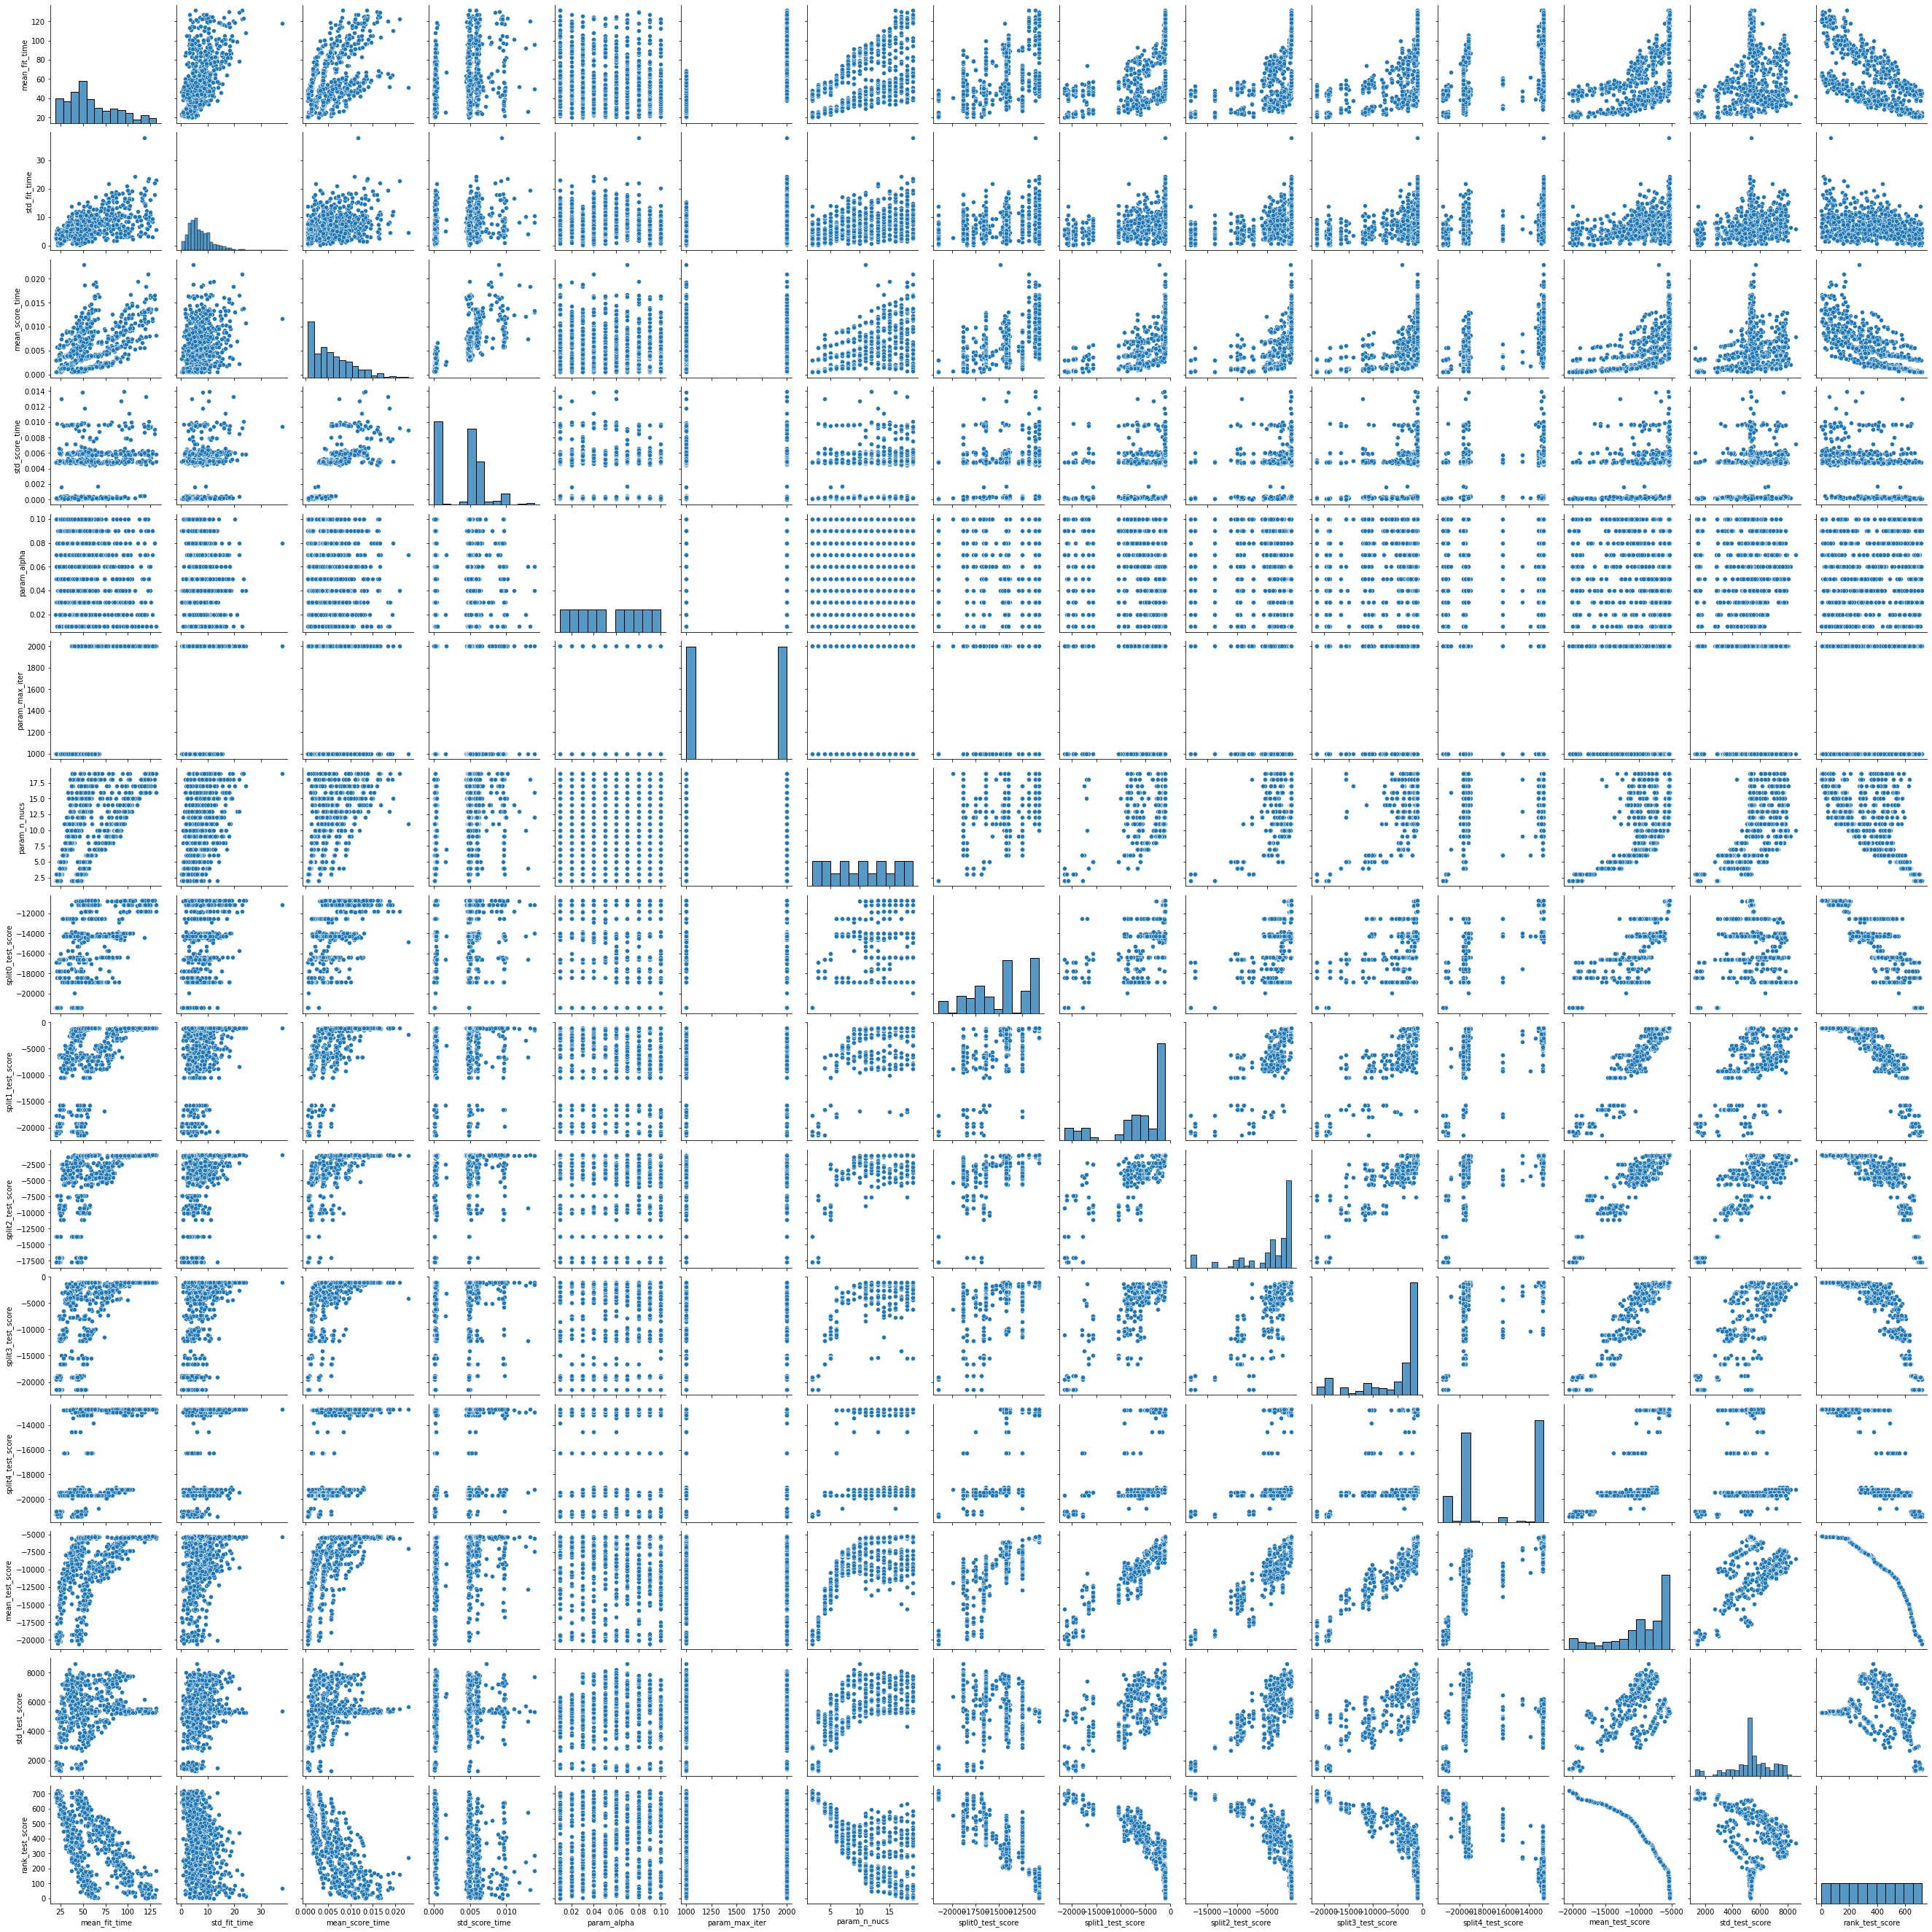

In [58]:
sns.pairplot(resdf)

<AxesSubplot:xlabel='mean_test_score', ylabel='Density'>

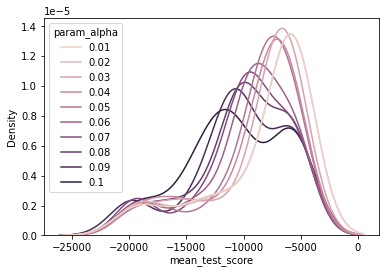

In [70]:
sns.kdeplot(data=resdf[['param_alpha', 'mean_test_score']], x='mean_test_score', hue='param_alpha')

<AxesSubplot:xlabel='mean_fit_time', ylabel='Density'>

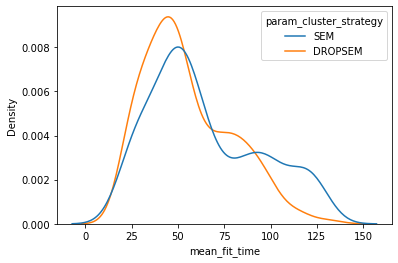

In [77]:
sns.kdeplot(data=resdf, x='mean_fit_time', hue='param_cluster_strategy')

<AxesSubplot:xlabel='mean_fit_time', ylabel='Density'>

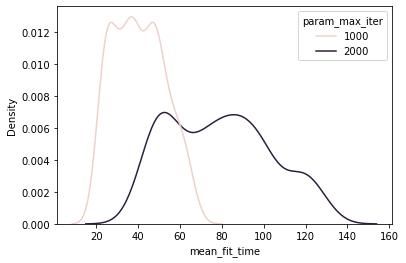

In [81]:
sns.kdeplot(data=resdf, x='mean_fit_time', hue='param_max_iter')

<AxesSubplot:xlabel='param_n_nucs', ylabel='mean_test_score'>

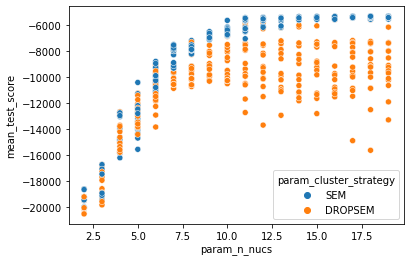

In [94]:
sns.scatterplot(data=resdf, x='param_n_nucs', y='mean_test_score', hue='param_cluster_strategy')

<AxesSubplot:xlabel='param_n_nucs', ylabel='mean_test_score'>

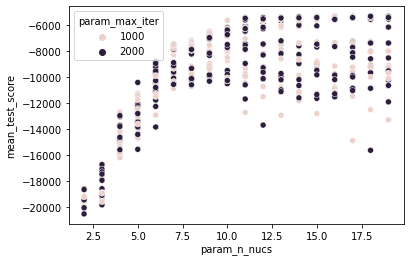

In [97]:
sns.scatterplot(data=resdf, x='param_n_nucs', y='mean_test_score', hue='param_max_iter')

In [118]:
resdf['rel_los'] = resdf.mean_test_score / resdf.param_n_nucs.T

In [122]:
resdf.sort_values('rel_los', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_cluster_strategy,param_max_iter,param_n_nucs,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,rel_los
35,120.638700,12.159107,0.013335,0.009450,0.01,SEM,2000,19,"{'alpha': 0.01, 'cluster_strategy': 'SEM', 'ma...",-10725.933394,-1015.955872,-1005.146442,-1019.924364,-12715.532785,-5296.498571,5282.966345,1.0,-278.763
593,62.484502,10.682556,0.016268,0.005074,0.09,SEM,1000,19,"{'alpha': 0.09, 'cluster_strategy': 'SEM', 'ma...",-10727.236113,-1006.849911,-995.341300,-1041.499772,-12715.312696,-5297.247958,5282.759975,3.0,-278.803
17,66.225742,9.261487,0.016651,0.004983,0.01,SEM,1000,19,"{'alpha': 0.01, 'cluster_strategy': 'SEM', 'ma...",-10727.786680,-1018.940650,-987.020011,-1040.656492,-12714.689607,-5297.818688,5282.229436,4.0,-278.833
467,126.979315,3.091415,0.016202,0.004763,0.07,SEM,2000,19,"{'alpha': 0.07, 'cluster_strategy': 'SEM', 'ma...",-10725.917506,-1056.594031,-1001.147568,-1018.564547,-12715.373697,-5303.519470,5277.226580,7.0,-279.133
611,127.195608,9.490009,0.011636,0.005929,0.09,SEM,2000,19,"{'alpha': 0.09, 'cluster_strategy': 'SEM', 'ma...",-10727.221073,-1052.291422,-999.132677,-1039.799067,-12714.718709,-5306.632590,5274.890748,10.0,-279.296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,45.737444,4.551466,0.000583,0.000123,0.03,DROPSEM,2000,2,"{'alpha': 0.03, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.153597,-17710.911661,-19462.148189,-21197.466887,-20111.544340,1378.274697,717.0,-10055.8
252,25.573494,2.815095,0.000571,0.000090,0.04,DROPSEM,1000,2,"{'alpha': 0.04, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.144295,-17710.911661,-19462.148189,-21414.041365,-20154.857375,1414.643703,718.0,-10077.4
612,21.849374,0.968139,0.000524,0.000136,0.09,DROPSEM,1000,2,"{'alpha': 0.09, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.125777,-17710.911661,-21414.041365,-21197.466887,-20501.917411,1414.990909,719.0,-10251
630,45.183354,5.879218,0.000513,0.000104,0.09,DROPSEM,2000,2,"{'alpha': 0.09, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.125777,-17710.911661,-21414.041365,-21414.041365,-20545.232306,1438.735312,720.0,-10272.6


In [124]:
gs_res.best_estimator_

EMNucModel(alpha=0.01, cluster_strategy='SEM',
           fit_res=array([1.43621777e-03, 8.61620150e-04, 4.43562938e-04, 2.40685385e-04,
       2.84158806e-04, 5.37725234e-04, 9.05284292e-04, 1.27619107e-03,
       1.52457358e-03, 1.56757311e-03, 1.44062835e-03, 1.16552947e-03,
       8.61546581e-04, 6.70886089e-04, 7.15798839e-04, 1.08152670e-03,
       1.73342920e-03, 2.51507892e-03, 3.13087598e-03, 3.338...
       9.38574762e-04, 8.22423123e-04, 7.33178542e-04, 6.17824261e-04,
       4.77234599e-04, 2.70483609e-04, 3.19629624e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.41687741e-05, 1.61108112e-04,
       2.07264553e-04, 1.30680998e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.25661451e-05, 1.95427263e-04,
       9.65275698e-05]),
           max_iter=2000, n_nucs=19)

<AxesSubplot:xlabel='mean_fit_time', ylabel='param_max_iter'>

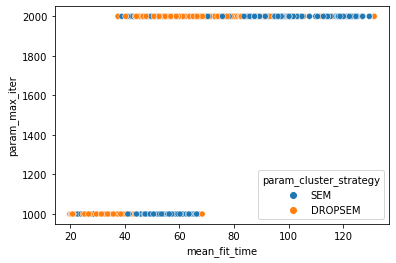

In [80]:
sns.scatterplot(data=resdf, x='mean_fit_time', y='param_max_iter', hue='param_cluster_strategy')

In [766]:
ntest_nucs = 5
read_amount = np.array([50, 30, 20, 10] * ntest_nucs)
assert ntest_nucs == len(read_amount)

internuc_dist = np.random.normal(200, 1, size=ntest_nucs - 1).astype(int)
start_pos = 150
nuc_pos = [start_pos]
test_nucs = []


for i in range(ntest_nucs - 1):
    new_pos = nuc_pos[i] + internuc_dist[i]
    nuc_pos.append(new_pos)
nuc_pos = np.array(nuc_pos)

for nofgroup in range(ntest_nucs):
    digestedNuc = dpst.digest_nucs(read_amount[nofgroup], nuc_pos[nofgroup], id_=nofgroup)
    test_nucs.extend(digestedNuc)

In [767]:
hue=list(map(lambda x: x.id, test_nucs))

In [768]:
test_batch = np.array(list(map(lambda x: [x.start, x.end], test_nucs)))

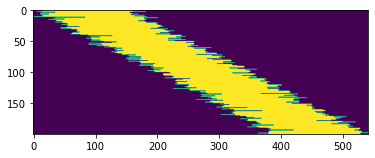

In [769]:
imshow = make_position_matrix(test_batch)
plt.imshow(imshow)

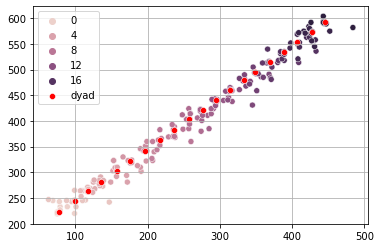

In [770]:
sns.scatterplot(x=test_batch[:, 0], y=test_batch[:, 1], hue=hue)
sns.scatterplot(x=nuc_pos -73, y=nuc_pos + 73, color='red', label='dyad')
plt.grid()

In [771]:
test_model = EMNucModel(ntest_nucs, 'SEM', dpst.fit_res, max_iter=1000)
test_model.fit(test_batch)

100%|██████████| 1000/1000 [00:43<00:00, 23.16it/s]


EMNucModel(cluster_strategy='SEM',
           fit_res=array([1.43621777e-03, 8.61620150e-04, 4.43562938e-04, 2.40685385e-04,
       2.84158806e-04, 5.37725234e-04, 9.05284292e-04, 1.27619107e-03,
       1.52457358e-03, 1.56757311e-03, 1.44062835e-03, 1.16552947e-03,
       8.61546581e-04, 6.70886089e-04, 7.15798839e-04, 1.08152670e-03,
       1.73342920e-03, 2.51507892e-03, 3.13087598e-03, 3.33821416e-03,
       2...
       9.38574762e-04, 8.22423123e-04, 7.33178542e-04, 6.17824261e-04,
       4.77234599e-04, 2.70483609e-04, 3.19629624e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.41687741e-05, 1.61108112e-04,
       2.07264553e-04, 1.30680998e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.25661451e-05, 1.95427263e-04,
       9.65275698e-05]),
           n_nucs=20)

In [772]:
test_model.model.gij

array([[0.        , 0.        , 0.78975059, ..., 0.        , 0.20966785,
        0.        ],
       [0.        , 0.        , 0.99051437, ..., 0.        , 0.00948563,
        0.        ],
       [0.        , 0.        , 0.16343397, ..., 0.        , 0.8163566 ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [773]:
w_test, pos_test = test_model.weights_, test_model.positions_

In [774]:
w_test

array([0.06 , 0.06 , 0.04 , 0.035, 0.075, 0.04 , 0.045, 0.06 , 0.025,
       0.065, 0.04 , 0.045, 0.075, 0.06 , 0.06 , 0.065, 0.04 , 0.   ,
       0.065, 0.045])

In [775]:
pos_test

array([270, 442, 149, 348, 500, 229, 191, 388, 290, 309, 406, 518, 460,
       367, 331, 209, 422,  63, 171, 249])

In [776]:
test_model.score(test_batch)

-1909.1348030337929

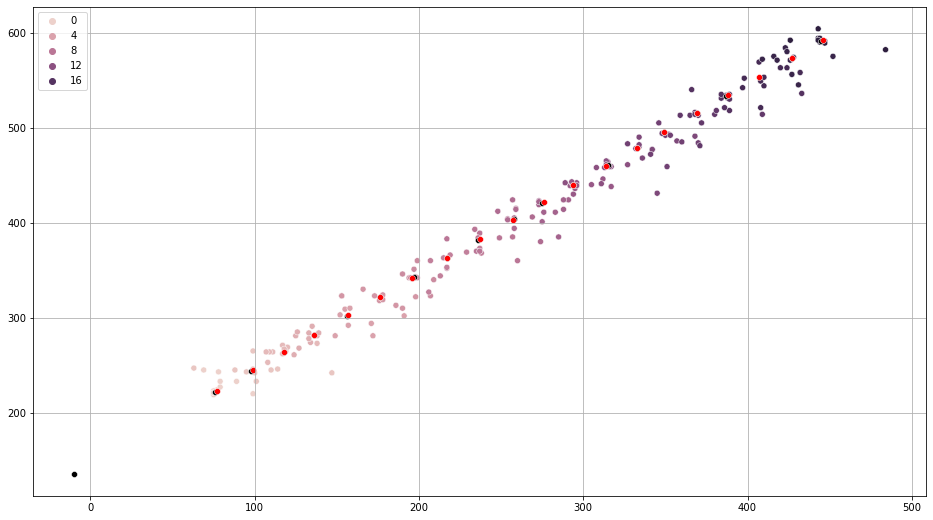

In [779]:
plt.figure(figsize=(16, 9))
sns.scatterplot(x=test_batch[:, 0], y=test_batch[:, 1], hue=list(map(lambda x: x.id, test_nucs)))
sns.scatterplot(x=pos_test -73, y=pos_test + 73, color='black')
sns.scatterplot(x=nuc_pos -73, y=nuc_pos + 73, color='red')
plt.grid()

In [780]:
print(nuc_pos, pos_test)

[150 172 191 209 230 249 269 290 310 330 349 367 387 406 422 442 461 480
 500 519] [270 442 149 348 500 229 191 388 290 309 406 518 460 367 331 209 422  63
 171 249]


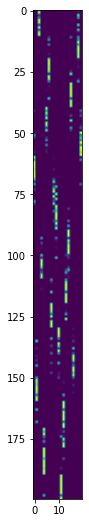

In [781]:
plt.figure(figsize=(16, 9))
plt.imshow(test_model.model.gij)

In [782]:
test_wd, test_stat = count_statistics(test_batch, test_model)

In [783]:
test_stat

,dyad,stat,size,p_vals
0,149,8.785507,7,0.268425
1,171,13.012824,14,0.525514
2,191,8.001687,9,0.533976
3,209,11.080402,12,0.522041
4,229,8.660626,8,0.371729
5,249,10.414836,9,0.317957
6,270,12.010589,13,0.526776
7,290,7.389771,5,0.193228
8,309,12.007726,13,0.527010
9,331,11.031508,11,0.440627


In [784]:
test_grid = {'n_nucs': np.arange(2, 10),
            'cluster_strategy': ['SEM', 'DROPSEM'],
            'alpha': np.arange(1, 11) / 100}
gs = GridSearchCV(EMNucModel(1, 'SEM', dpst.fit_res, 1000), test_grid, n_jobs=4, verbose=True)

In [725]:
gs_res = gs.fit(test_batch)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py:63: UserWarning: Failed to kill subprocesses on this platform. Please installpsutil: https://github.com/giampaolo/psutil
Details:
Traceback (most recent call last):
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py", line 59, in _kill_process_tree_without_psutil
    _posix_recursive_kill(process.pid)
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py", line 111, in _posix_recursive_kill
    ["pgrep", "-P", str(pid)], stderr=None, text=True
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/subprocess.py", line 356, in check_output
    **kwargs).stdout
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/subprocess.py", line 423, in run
    with Popen(*popenargs, **kwargs) as process:
TypeError: __init__() got an unexpected keyword argument 'text'

 

ValueError: Invalid parameter alpha for estimator EMNucModel(cluster_strategy='SEM',
           fit_res=array([1.43621777e-03, 8.61620150e-04, 4.43562938e-04, 2.40685385e-04,
       2.84158806e-04, 5.37725234e-04, 9.05284292e-04, 1.27619107e-03,
       1.52457358e-03, 1.56757311e-03, 1.44062835e-03, 1.16552947e-03,
       8.61546581e-04, 6.70886089e-04, 7.15798839e-04, 1.08152670e-03,
       1.73342920e-03, 2.51507892e-03, 3.13087598e-03, 3.33821416e-03,
       2...
       9.38574762e-04, 8.22423123e-04, 7.33178542e-04, 6.17824261e-04,
       4.77234599e-04, 2.70483609e-04, 3.19629624e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.41687741e-05, 1.61108112e-04,
       2.07264553e-04, 1.30680998e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.25661451e-05, 1.95427263e-04,
       9.65275698e-05]),
           n_nucs=1). Check the list of available parameters with `estimator.g

In [698]:
gsdf_test = pd.DataFrame(gs_res.cv_results_)

In [699]:
gsdf_test

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_cluster_strategy,param_n_nucs,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.057413,0.147268,0.000953,0.000726,SEM,1,"{'cluster_strategy': 'SEM', 'n_nucs': 1}",-inf,-44.376548,-inf,-41.844225,-49.466187,-inf,NaN,17
1,2.096095,0.063568,0.000390,0.000033,SEM,2,"{'cluster_strategy': 'SEM', 'n_nucs': 2}",-29.587851,-27.718016,-37.750355,-33.975475,-35.754496,-32.957239,3.758660,12
2,2.276072,0.025925,0.001370,0.001143,SEM,3,"{'cluster_strategy': 'SEM', 'n_nucs': 3}",-29.058383,-27.718016,-37.716563,-33.975475,-39.495923,-33.592872,4.627586,15
3,2.434089,0.020872,0.000491,0.000050,SEM,4,"{'cluster_strategy': 'SEM', 'n_nucs': 4}",-30.198259,-27.718016,-37.716563,-33.975475,-34.775996,-32.876862,3.522072,10
4,2.623920,0.042968,0.000526,0.000041,SEM,5,"{'cluster_strategy': 'SEM', 'n_nucs': 5}",-30.918901,-26.710532,-37.716563,-33.975475,-39.495923,-33.763479,4.612340,16
5,2.798548,0.020571,0.000720,0.000070,SEM,6,"{'cluster_strategy': 'SEM', 'n_nucs': 6}",-29.650790,-26.710532,-37.716563,-33.703188,-34.775996,-32.511414,3.885245,3
6,2.978057,0.074913,0.000767,0.000074,SEM,7,"{'cluster_strategy': 'SEM', 'n_nucs': 7}",-29.580405,-27.319777,-37.716563,-33.975475,-35.754496,-32.869343,3.864142,9
7,3.125528,0.047958,0.000743,0.000063,SEM,8,"{'cluster_strategy': 'SEM', 'n_nucs': 8}",-29.650790,-28.434498,-37.716563,-33.703188,-34.775996,-32.856207,3.401536,8
8,3.320177,0.060580,0.000872,0.000076,SEM,9,"{'cluster_strategy': 'SEM', 'n_nucs': 9}",-29.650790,-27.718016,-37.800872,-33.975475,-35.754496,-32.979930,3.760365,13
9,1.875288,0.018414,0.000578,0.000593,DROPSEM,1,"{'cluster_strategy': 'DROPSEM', 'n_nucs': 1}",-inf,-44.376548,-inf,-41.844225,-49.466187,-inf,NaN,17


<AxesSubplot:xlabel='mean_test_score', ylabel='mean_test_score'>

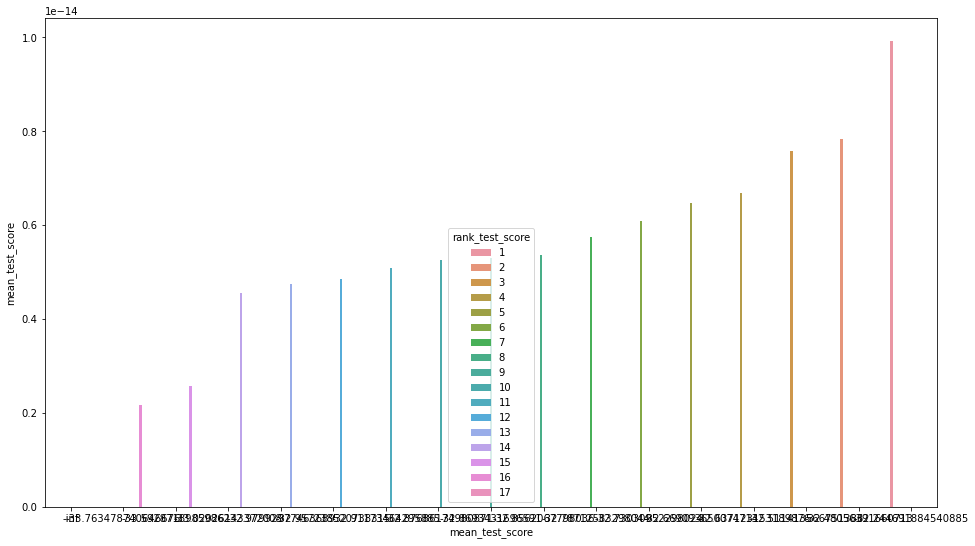

In [700]:
plt.figure(figsize=(16, 9))
sns.barplot(data=gsdf_test, x='mean_test_score', y=np.exp(gsdf_test.mean_test_score), hue='rank_test_score')

In [712]:
best_test_wd, best_test_stat = count_statistics(test_batch, gs_res.best_estimator_)

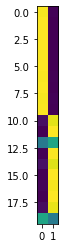

In [713]:
plt.imshow(gs_res.best_estimator_.model.gij)

In [714]:
best_model = gs_res.best_estimator_

In [715]:
best_test_wd, best_test_stat = count_statistics(test_batch, best_model)

In [716]:
best_test_stat

,dyad,stat,size,p_vals
0,150,12.116631,11,0.354941
1,171,9.794589,9,0.367369


In [717]:
test_stat

,dyad,stat,size,p_vals
0,150,12.116631,11,0.354941
1,171,9.794589,9,0.367369


In [718]:
best_test_wd.head()

,start,stop,mid,dyad,nuc_prob,prob,stat
0,72,225,148.5,150,0.55,0.992065,0.066820
1,77,226,151.5,150,0.55,0.996112,0.066820
2,77,193,135.0,150,0.55,1.000000,6.681965
3,67,224,145.5,150,0.55,0.998454,0.601377
4,77,227,152.0,150,0.55,0.995611,0.118790


In [723]:
best_model

EMNucModel(cluster_strategy='DROPSEM',
           fit_res=array([1.43621777e-03, 8.61620150e-04, 4.43562938e-04, 2.40685385e-04,
       2.84158806e-04, 5.37725234e-04, 9.05284292e-04, 1.27619107e-03,
       1.52457358e-03, 1.56757311e-03, 1.44062835e-03, 1.16552947e-03,
       8.61546581e-04, 6.70886089e-04, 7.15798839e-04, 1.08152670e-03,
       1.73342920e-03, 2.51507892e-03, 3.13087598e-03, 3.33821416e-...
       9.38574762e-04, 8.22423123e-04, 7.33178542e-04, 6.17824261e-04,
       4.77234599e-04, 2.70483609e-04, 3.19629624e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.41687741e-05, 1.61108112e-04,
       2.07264553e-04, 1.30680998e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.25661451e-05, 1.95427263e-04,
       9.65275698e-05]),
           n_nucs=3)

In [709]:
best_model.positions_

array([150, 171])

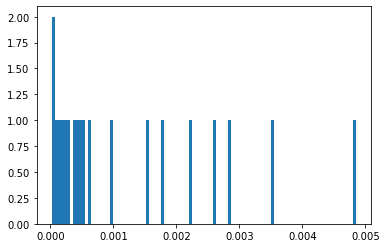

In [710]:
_ = plt.hist(test_model.model.X.sum(axis=1), bins=100)

In [711]:
best_model.model.weights

array([0.55, 0.45])